# Processing an image

This notebook runs the hGRS processing chain on an EnMAP L1C image of Lake Trasimeno (Italy, 17 August
2024) and looks at the retrieved atmospheric parameters and remote-sensing reflectance. The steps and
equations are described in [Methods](../methods.rst).

In [1]:
import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import hgrs

opj = os.path.join
hgrs.__version__

'1.1.2'

## Input files

- the EnMAP L1C product (directory); for PRISMA, give the list `[l1_path, l2c_path]` of the L1 and L2C
  files instead,
- the CAMS file covering the acquisition date,
- the output directory.

In [2]:
l1c_path = '/data/satellite/enmap/EnMAP_L1C/Trasimeno/ENMAP01-____L1C-DT0000088121_20240817T102235Z_002_V010502_20250128T220420Z'
cams_file = '/data/cams/world/cams_forecast_2024-08.nc'

odir = 'L2A'
outfile = opj(odir, os.path.basename(l1c_path).replace('L1C', 'L2A_hgrs') + '_V' + hgrs.__version__ + '.nc')

## Run the processing

`Process.execute` reads the image, the CAMS data and the look-up tables, then runs the masking, the
gaseous correction, the water vapor and aerosol retrievals on the coarse grid and the correction at
full resolution.

In [3]:
%%time
process = hgrs.Process()
process.execute(l1c_path, cams_file)
process.successful

INFO:root:construct L1C image plus angle rasters
INFO:root:Opening EnMAP image
INFO:root:Create hGRS object
INFO:root:Load pre-computed radiative transfer LUT
INFO:root:get CAMS and set atmospheric parameters
INFO:root:OPAC model: MACL_rh70
INFO:root:Apply omnicloudmask
INFO:root:Apply water masking
INFO:root:Construct coarse resolution raster
INFO:root:Correct for gaseous absorption
INFO:root:water vapor retrieval and correction
INFO:root:mask bands where gaseous abs. is too strong
INFO:root:aerosol retrieval
INFO:root:process full resolution
INFO:root:construct final product
CPU times: user 4min 1s, sys: 1min 43s, total: 5min 45s
Wall time: 2min 56s


True

The L2A product is an `xarray.Dataset`: `Rrs` and `brdfg_full` at full resolution (`x`, `y`), the
retrieved parameters on the coarse grid (`xc`, `yc`, mega-pixels of 20 x 20 pixels).

In [4]:
l2_prod = process.l2_prod
l2_prod

<xarray.Dataset> Size: 3GB
Dimensions:           (wl: 181, y: 1247, x: 1598, yc: 63, xc: 80)
Coordinates:
  * x                 (x) float64 13kB 2.431e+05 2.431e+05 ... 2.91e+05
    spatial_ref       int64 8B 0
    time              datetime64[ns] 8B 2024-08-17T10:22:30.993191
  * y                 (y) float64 10kB 4.8e+06 4.8e+06 ... 4.763e+06 4.763e+06
  * wl                (wl) float64 1kB 418.4 424.0 429.5 ... 2.438e+03 2.445e+03
  * xc                (xc) float64 640B 2.433e+05 2.439e+05 ... 2.907e+05
  * yc                (yc) float64 504B 4.8e+06 4.799e+06 ... 4.763e+06
Data variables: (12/13)
    Rrs               (wl, y, x) float64 3GB nan nan nan nan ... nan nan nan nan
    brdfg_full        (y, x) float32 8MB nan nan nan nan nan ... nan nan nan nan
    tcwv              (yc, xc) float64 40kB nan nan nan nan ... nan nan nan nan
    tcwv_std          (yc, xc) float64 40kB nan nan nan nan ... nan nan nan nan
    aot_ref           (yc, xc) float64 40kB nan nan nan nan ... nan nan nan nan
    brdfg             (yc, xc) float64 40kB nan nan nan nan ... nan nan nan nan
    ...                ...
    brdfg_std         (yc, xc) float64 40kB nan nan nan nan ... nan nan nan nan
    aot_ref_smoothed  (yc, xc) float64 40kB nan nan nan nan ... nan nan nan nan
    water_pix_prop    (yc, xc) float64 40kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pressure          float64 8B 973.8
    to3c              float64 8B 0.006291
    tno2c             float64 8B 3.003e-06
Attributes: (12/42)
    description:                     PRISMA L2A-hGRS cube data
    L1C_product_name:                ENMAP01-____L1C-DT0000088121_20240817T10...
    acquisition_date:                2024-08-17 10:22:30.993191
    vnir_index:                      [  0   1   2   3   4   5   6   7   8   9...
    swir_index:                      [ 79  81  84  86  88  90  93  95  97  99...
    vnir_index_tokeep:               [ 0  1  2  3  4  5  6  7  8  9 10 11 12 ...
    ...                              ...
    to3c:                            0.0062910388223826885
    tno2c:                           3.0029445952095557e-06
    tch4c:                           0.009911714121699333
    psl:                             1013
    coef_abs_scat:                   0.35
    altitude:                        0

The maps below are zoomed on Lake Trasimeno (and the small Lake Montepulciano on the west), in the
UTM coordinates of the image.

In [5]:
zoom = dict(x=slice(247000, 273000), y=slice(4788000, 4772000))   # y is decreasing

## TOA reflectance and remote-sensing reflectance

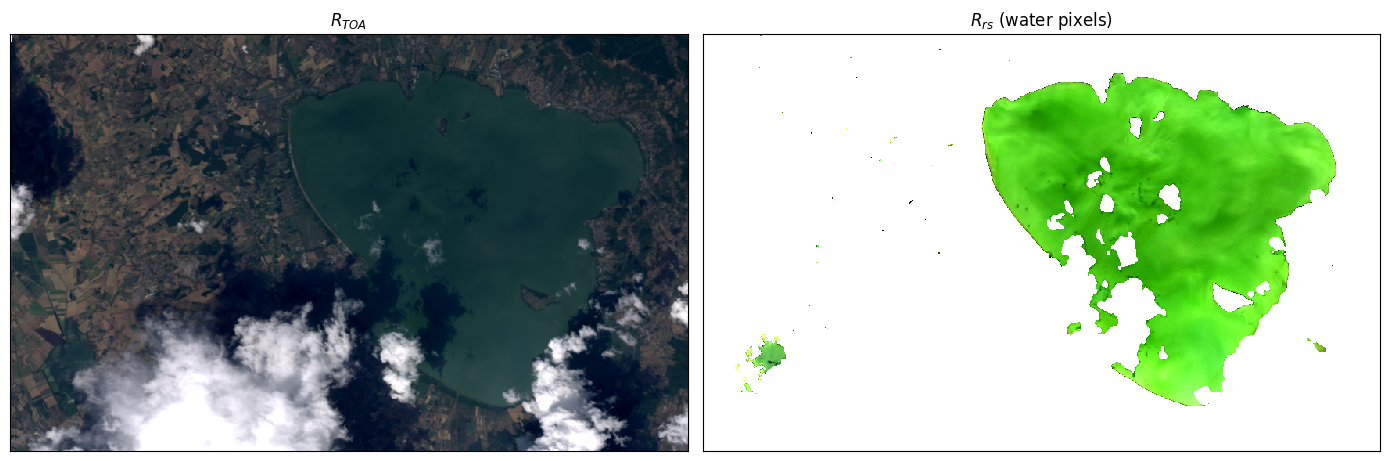

In [6]:
l1_prod = process.l1_prod
rgb_wl = [650, 560, 480]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
(l1_prod.Rtoa.sel(wl=rgb_wl, method='nearest').sel(**zoom) ** 0.5).plot.imshow(rgb='wl', robust=True, ax=axs[0])
axs[0].set_title('$R_{TOA}$')
l2_prod.Rrs.sel(wl=rgb_wl, method='nearest').sel(**zoom).plot.imshow(rgb='wl', robust=True, ax=axs[1])
axs[1].set_title('$R_{rs}$ (water pixels)')
for ax in axs:
    ax.set(xticks=[], yticks=[], xlabel='', ylabel='', aspect='equal')
plt.tight_layout()

## Retrieved atmospheric parameters

Water vapor column $W$ (`tcwv`), aerosol optical thickness at 550 nm $\tau_{ref}$ before and after
smoothing (`aot_ref`, `aot_ref_smoothed`) and sunglint amplitude $B$ (`brdfg`) on the coarse grid, with
the proportion of water pixels of each mega-pixel and $B$ at full resolution (`brdfg_full`).

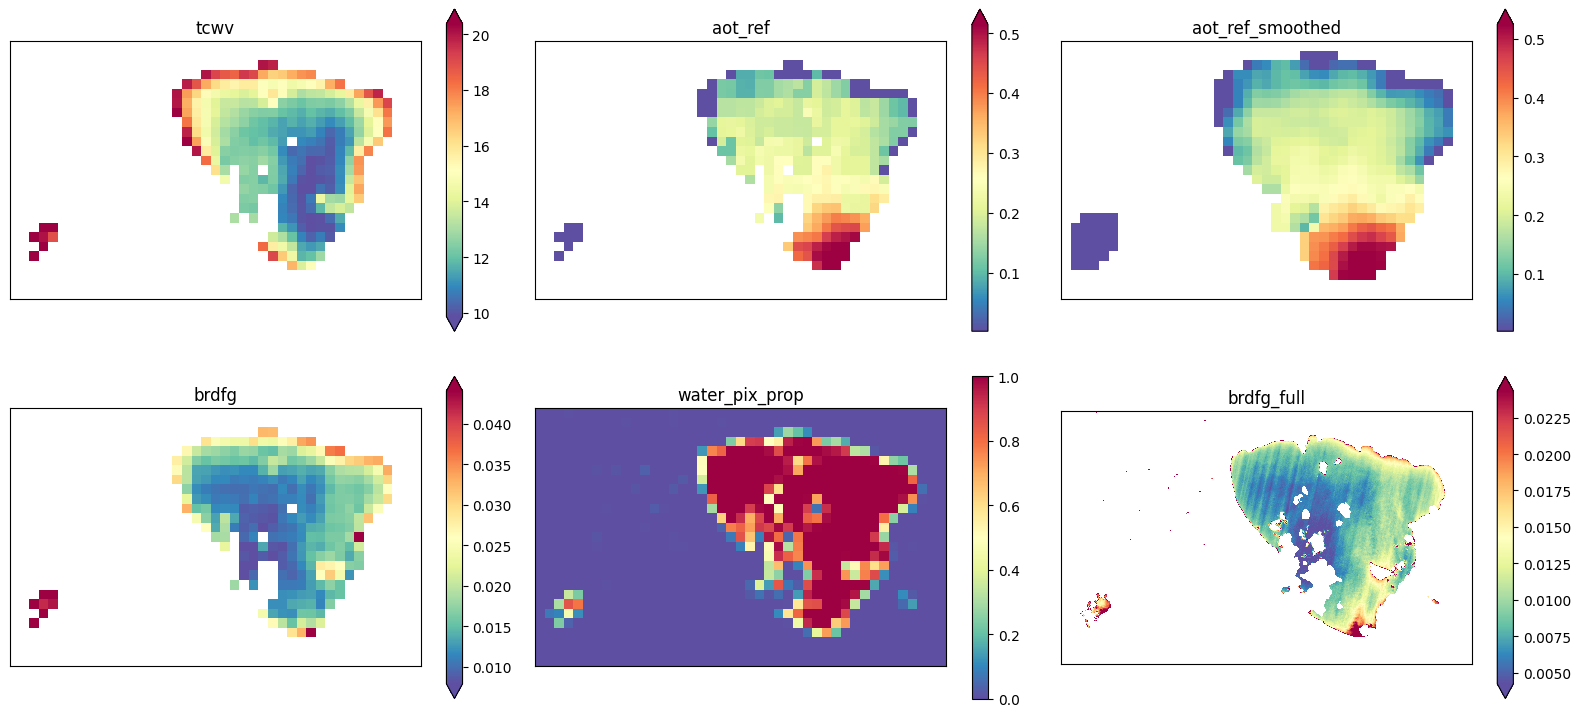

In [7]:
params = ['tcwv', 'aot_ref', 'aot_ref_smoothed', 'brdfg', 'water_pix_prop', 'brdfg_full']

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
for param, ax in zip(params, axs.ravel()):
    data = l2_prod[param]
    if 'xc' in data.dims:   # coarse grid
        data = data.sel(xc=zoom['x'], yc=zoom['y'])
    else:
        data = data.sel(**zoom)
    data.plot.imshow(cmap=plt.cm.Spectral_r, robust=True, ax=ax,
                     cbar_kwargs={'shrink': 0.8, 'label': ''})
    ax.set(xticks=[], yticks=[], xlabel='', ylabel='', title=param, aspect='equal')
plt.tight_layout()

## Atmospheric terms

The atmospheric terms of the image (`atmo_img`, averaged over the coarse grid): diffuse reflectance
$R_{diff}(\lambda)$, direct transmittance $T_{dir}(\lambda)$ and spectral aerosol optical thickness
$\tau_a(\lambda)$, with the spectral shape of the sunglint $\varepsilon(\lambda)$.

aerosol model: MACL_rh70


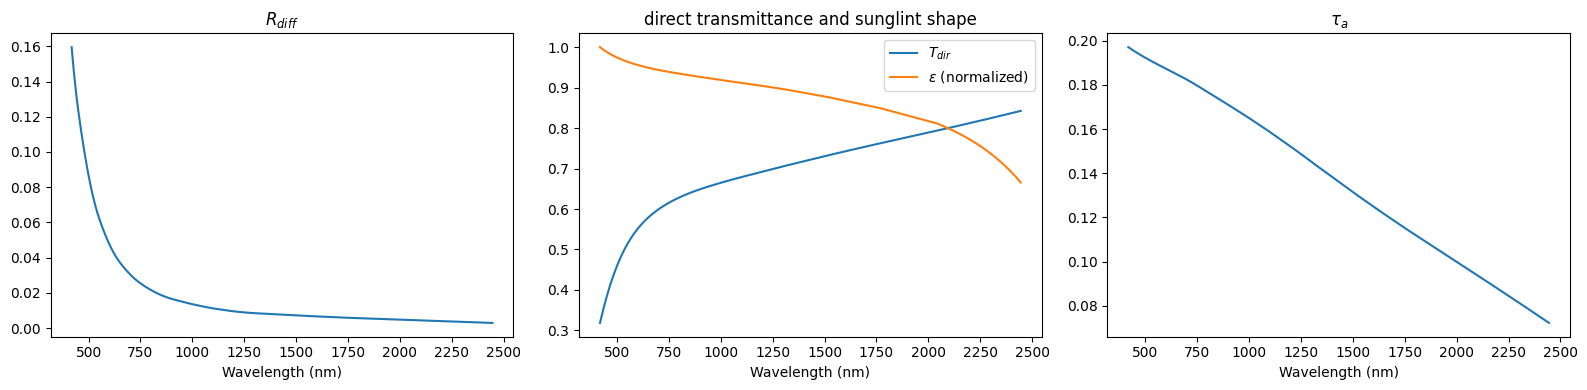

In [8]:
aero = process.aero_retrieval
atmo = aero.atmo_img.mean(['x', 'y'])
print('aerosol model:', aero.aerosol_model)

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
atmo.Rtoa_diff.plot(ax=axs[0])
axs[0].set(title='$R_{diff}$', ylabel='')
atmo.Tdir.plot(ax=axs[1], label='$T_{dir}$')
(aero.sunglint_eps / aero.sunglint_eps.max()).plot(ax=axs[1], label=r'$\varepsilon$ (normalized)')
axs[1].set(title='direct transmittance and sunglint shape', ylabel='')
axs[1].legend()
atmo.aot.plot(ax=axs[2])
axs[2].set(title=r'$\tau_a$', ylabel='')
for ax in axs:
    ax.set_xlabel('Wavelength (nm)')
plt.tight_layout()

## Remote-sensing reflectance

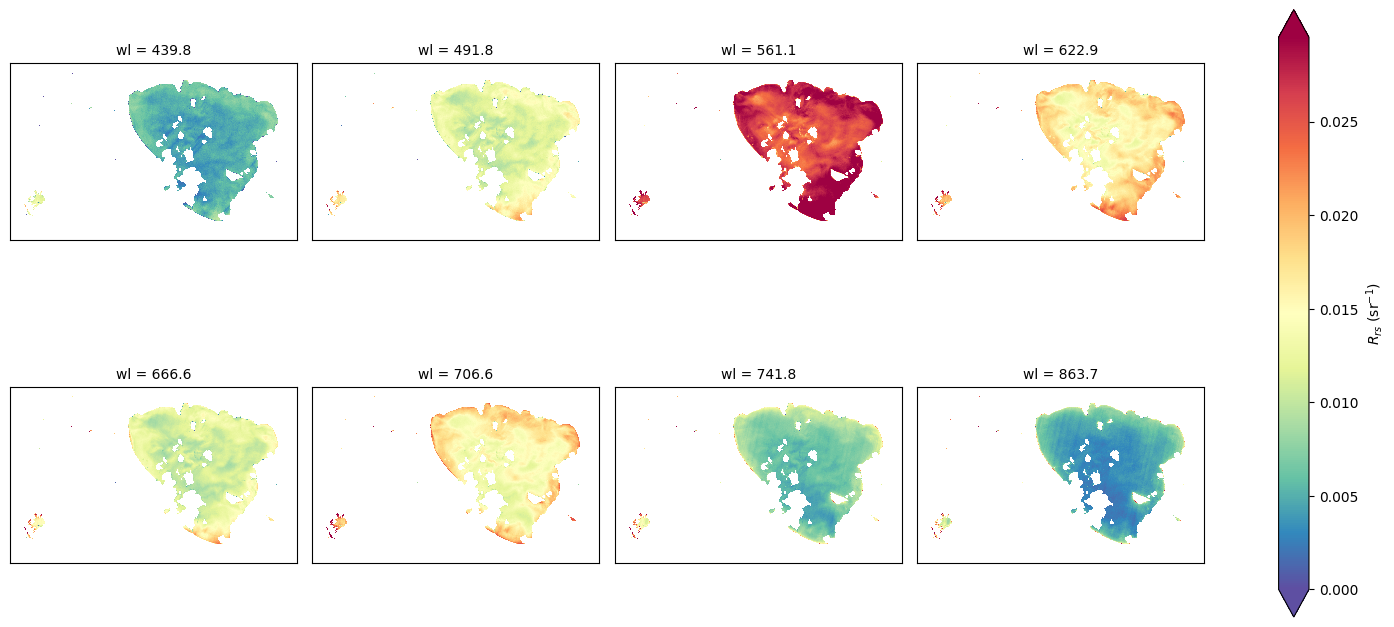

In [9]:
subset = l2_prod.Rrs.sel(wl=[440, 490, 560, 620, 665, 705, 740, 865], method='nearest').sel(**zoom)
fig = subset.plot.imshow(col='wl', col_wrap=4, vmin=0, robust=True, cmap=plt.cm.Spectral_r,
                         figsize=(16, 7), cbar_kwargs={'label': '$R_{rs}$ (sr$^{-1}$)'})
for ax in fig.axs.flat:
    ax.set(xticks=[], yticks=[], xlabel='', ylabel='', aspect='equal')

Spectra of a few water pixels, chosen along the gradient of $R_{rs}(705)$:

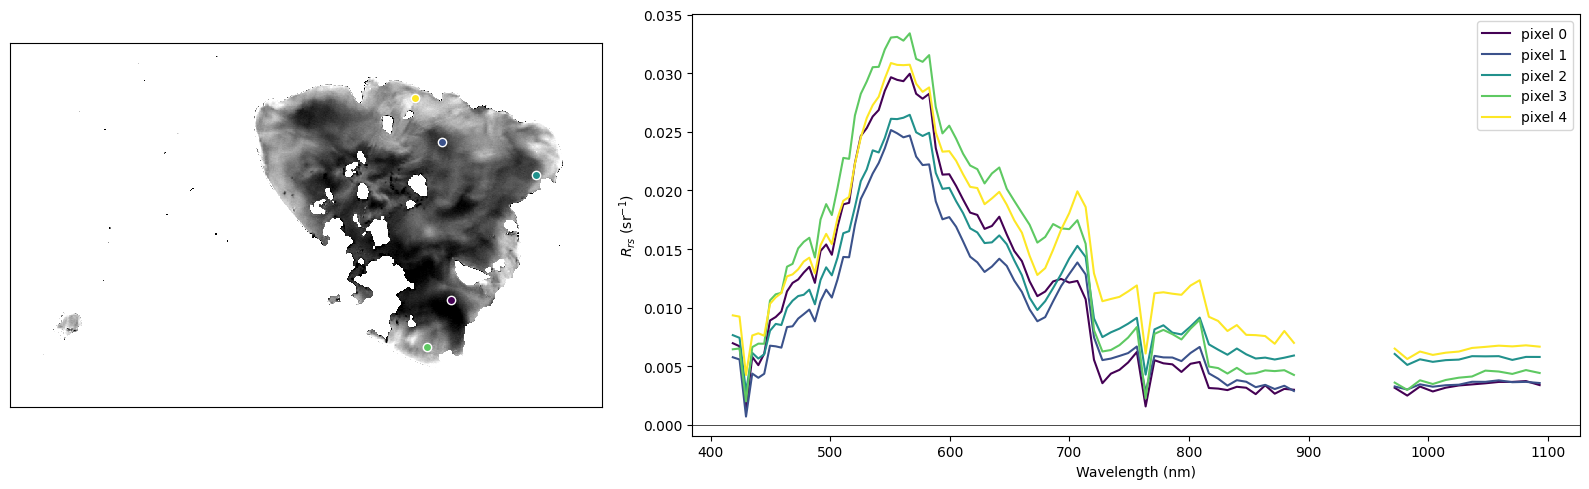

In [10]:
r705 = l2_prod.Rrs.sel(wl=705, method='nearest')
valid = r705.where(r705.notnull()).stack(pixel=['y', 'x']).dropna('pixel')
quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]
pixels = [valid.pixel.values[np.argmin(np.abs(valid.values - valid.quantile(q).values))] for q in quantiles]

fig, axs = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1, 1.5]})
r705.sel(**zoom).plot.imshow(cmap=plt.cm.gray, robust=True, ax=axs[0], add_colorbar=False)
for i, (y, x) in enumerate(pixels):
    color = plt.cm.viridis(i / (len(pixels) - 1))
    axs[0].plot(x, y, 'o', color=color, mec='white')
    l2_prod.Rrs.sel(x=x, y=y, wl=slice(400, 1100)).plot(ax=axs[1], color=color, label=f'pixel {i}')
axs[0].set(xticks=[], yticks=[], xlabel='', ylabel='', title='', aspect='equal')
axs[1].axhline(0, color='k', lw=0.5)
axs[1].set(xlabel='Wavelength (nm)', ylabel='$R_{rs}$ (sr$^{-1}$)', title='')
axs[1].legend()
plt.tight_layout()

## Save the product

The product is written into a compressed NetCDF file, for the wavelengths 400-1150 nm (see
[Usage](../usage.rst) for the variables).

In [11]:
process.write_output(outfile)
outfile

INFO:root:export final product into netcdf


'L2A/ENMAP01-____L2A_hgrs-DT0000088121_20240817T102235Z_002_V010502_20250128T220420Z_V1.1.2.nc'